Dimensiones del dataset: (768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Duplicados: 0
Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                       

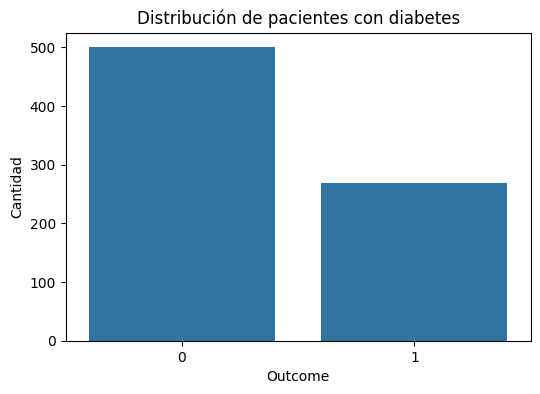

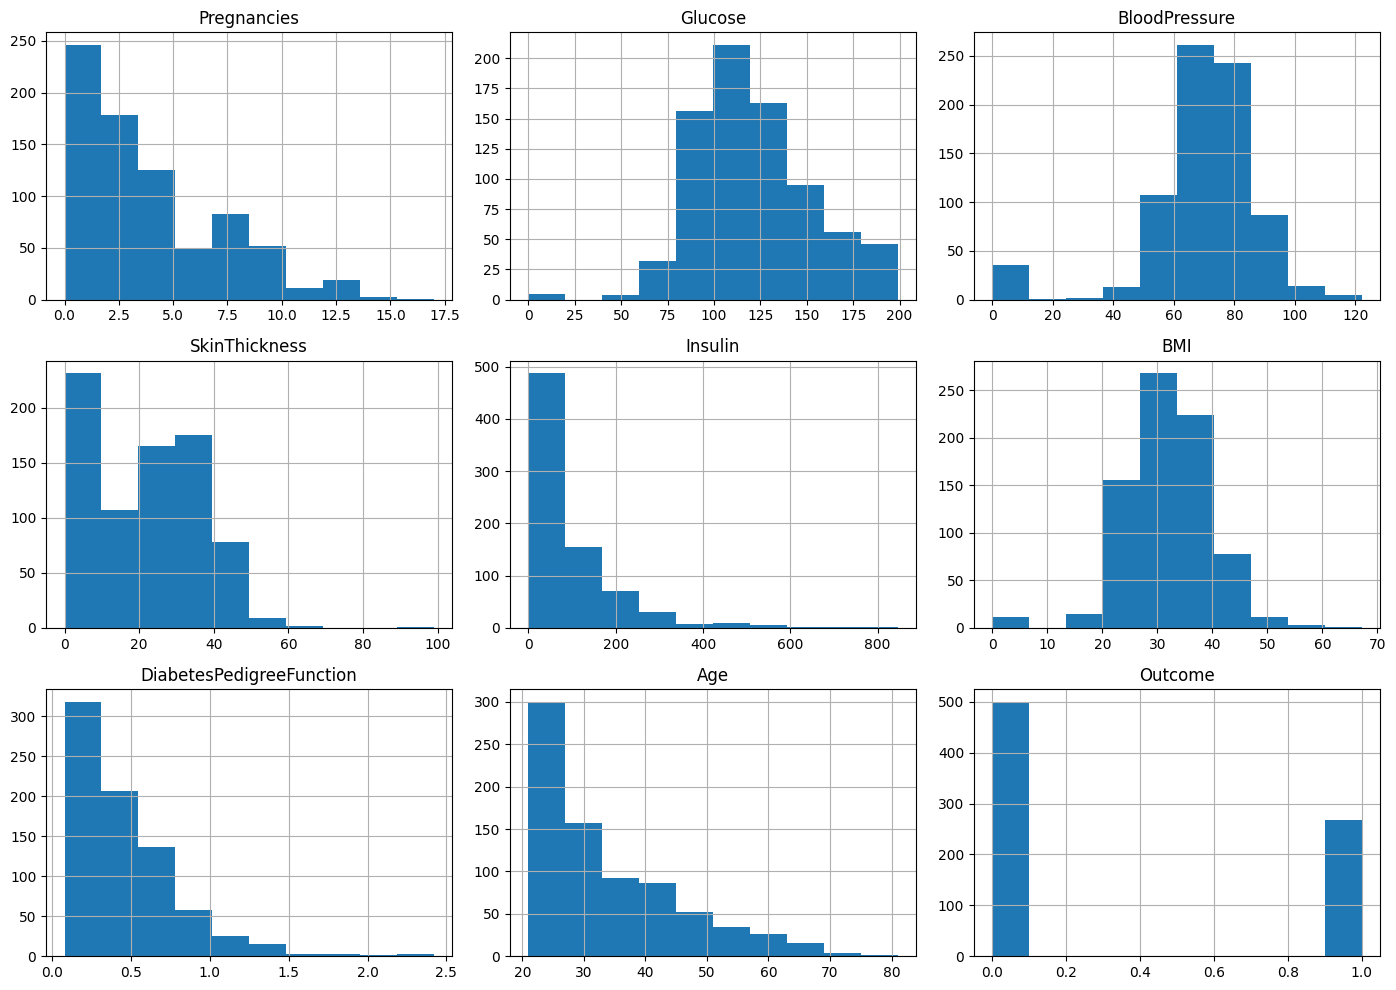

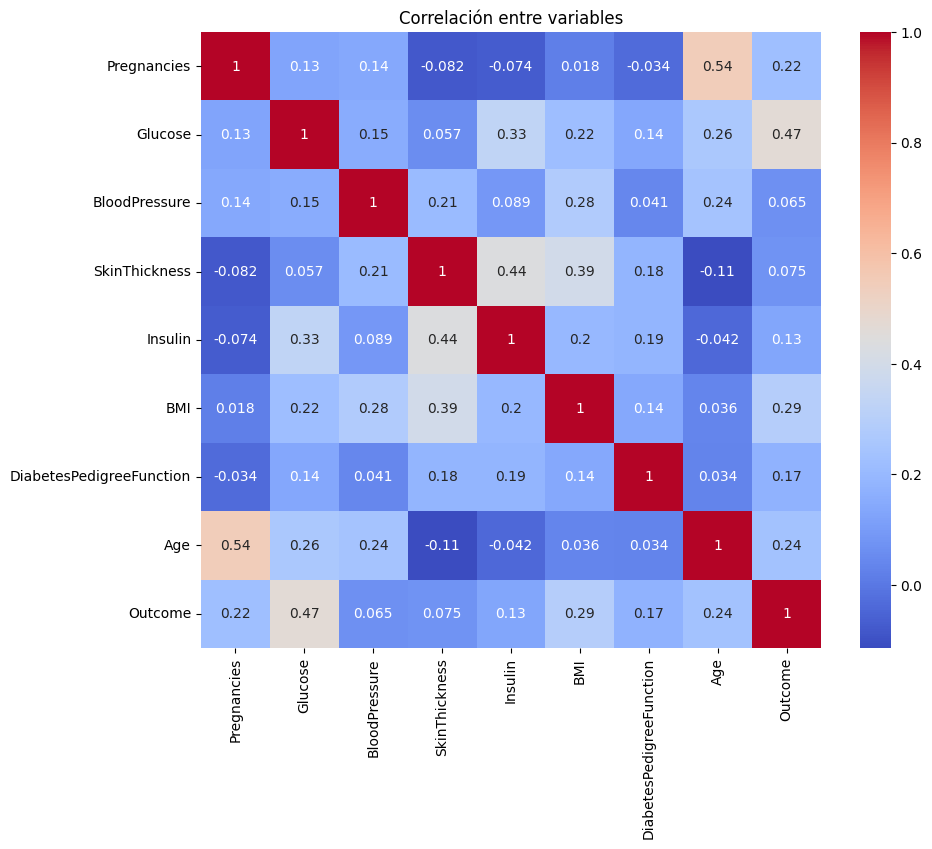

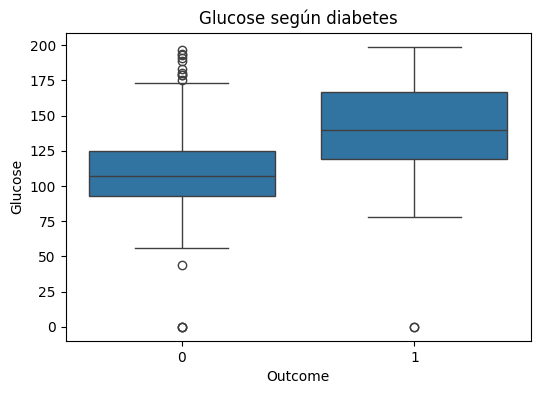

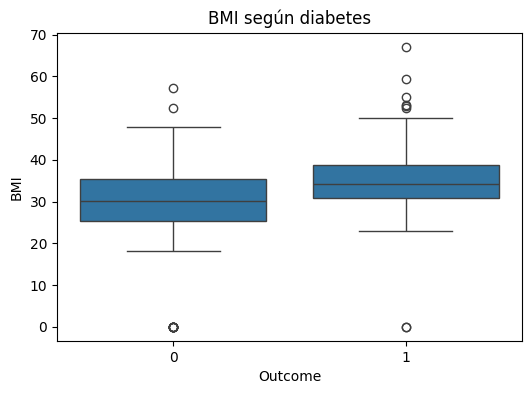

Variable analizada: Insulin
IQR: 127.25
Límite superior: 318.125
Límite inferior: -190.875


CONCLUSIÓN DEL EDA:

El dataset contiene información médica de pacientes
relacionada con el diagnóstico de diabetes.

No se detectan problemas importantes de valores nulos
ni duplicados significativos.

Variables como Glucose, BMI y Age muestran relación
con la variable objetivo Outcome.

Se observan posibles outliers en variables médicas
como Insulin, aunque pueden ser coherentes clínicamente.

El dataset es adecuado para aplicar modelos de clasificación
como Árboles de Decisión, Random Forest y Boosting.




In [5]:
# =========================================
# EDA COMPLETO - DATASET DIABETES
# =========================================

# =========================
# IMPORTACIÓN DE LIBRERÍAS
# =========================

# pandas -> trabajar con tablas y datasets
# matplotlib y seaborn -> visualización de datos
# os -> creación de carpetas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================
# CARGA DEL DATASET
# =========================

# Cargamos el dataset desde la URL oficial
# Este dataset contiene información médica de pacientes
# y servirá para predecir si una persona tiene diabetes o no

total_data = pd.read_csv(
    "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
)

# Mostramos las primeras filas
# para entender la estructura inicial del dataset

total_data.head()

# =========================
# GUARDAR DATOS RAW
# =========================

# Creamos las carpetas necesarias
# exist_ok=True evita errores si ya existen

os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

# Guardamos una copia de los datos originales

total_data.to_csv("../data/raw/diabetes_raw.csv", index=False)

# =========================
# EXPLORACIÓN GENERAL
# =========================

# Mostramos las dimensiones del dataset
# shape devuelve filas y columnas

print("Dimensiones del dataset:", total_data.shape)

# Información general
# Nos permite ver:
# - tipos de datos
# - valores no nulos
# - cantidad de registros

total_data.info()

"""
El dataset contiene variables médicas relacionadas con diabetes.

Cada fila representa un paciente y la variable objetivo es:
Outcome:
0 -> No diabetes
1 -> Diabetes
"""

# =========================
# ELIMINAR DUPLICADOS
# =========================

# Comprobamos registros duplicados

print("Duplicados:", total_data.duplicated().sum())

# Eliminamos duplicados y reorganizamos índices

total_data = total_data.drop_duplicates().reset_index(drop=True)

# =========================
# VALORES NULOS
# =========================

# Verificamos si existen valores nulos

print("Valores nulos por columna:")
print(total_data.isnull().sum())

"""
No se observan valores nulos explícitos en el dataset.

Sin embargo, algunas variables contienen valores 0
que podrían representar datos faltantes en variables médicas.
"""

# =========================
# ESTADÍSTICAS DESCRIPTIVAS
# =========================

# Estadísticas básicas:
# media, desviación, mínimos, máximos, etc.

total_data.describe()

"""
Las variables presentan escalas muy diferentes.

Algunas columnas como Insulin o Glucose
presentan alta dispersión y posibles valores extremos.
"""

# =========================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# =========================

# Visualizamos la cantidad de pacientes
# con y sin diabetes

plt.figure(figsize=(6,4))

sns.countplot(x="Outcome", data=total_data)

plt.title("Distribución de pacientes con diabetes")
plt.xlabel("Outcome")
plt.ylabel("Cantidad")

plt.show()

"""
La variable objetivo se encuentra relativamente equilibrada.

Esto es positivo para el entrenamiento del modelo,
ya que evita un fuerte desbalance de clases.
"""

# =========================
# DISTRIBUCIÓN DE VARIABLES
# =========================

# Histogramas de todas las variables numéricas

total_data.hist(figsize=(14,10))

plt.tight_layout()
plt.show()

"""
Se observan diferentes distribuciones entre variables.

Algunas variables presentan sesgo y posibles outliers,
especialmente Insulin y DiabetesPedigreeFunction.
"""

# =========================
# MATRIZ DE CORRELACIÓN
# =========================

# Analizamos la relación entre variables numéricas

plt.figure(figsize=(10,8))

sns.heatmap(
    total_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlación entre variables")

plt.show()

"""
Glucose muestra una de las correlaciones más fuertes con Outcome.

BMI y Age también parecen influir en la presencia de diabetes.

Estas relaciones serán importantes para el modelo predictivo.
"""

# =========================
# RELACIONES IMPORTANTES
# =========================

# Glucose vs Outcome

plt.figure(figsize=(6,4))

sns.boxplot(data=total_data, x="Outcome", y="Glucose")

plt.title("Glucose según diabetes")

plt.show()

"""
Los pacientes con diabetes suelen presentar
niveles de glucosa más elevados.
"""

# BMI vs Outcome

plt.figure(figsize=(6,4))

sns.boxplot(data=total_data, x="Outcome", y="BMI")

plt.title("BMI según diabetes")

plt.show()

"""
Se observa una tendencia a mayor BMI
en pacientes diagnosticados con diabetes.
"""

# =========================
# DETECCIÓN DE OUTLIERS
# =========================

# Detectamos valores extremos usando IQR

col = "Insulin"

stats = total_data[col].describe()

iqr = stats["75%"] - stats["25%"]

upper_limit = stats["75%"] + 1.5 * iqr
lower_limit = stats["25%"] - 1.5 * iqr

print(f"Variable analizada: {col}")
print(f"IQR: {iqr}")
print(f"Límite superior: {upper_limit}")
print(f"Límite inferior: {lower_limit}")

"""
JUSTIFICACIÓN:

Se utiliza el método IQR para detectar outliers.

En datasets médicos es habitual encontrar valores extremos,
aunque algunos pueden ser reales y clínicamente relevantes.
"""

# =========================
# CONCLUSIÓN FINAL DEL EDA
# =========================

print("""

CONCLUSIÓN DEL EDA:

El dataset contiene información médica de pacientes
relacionada con el diagnóstico de diabetes.

No se detectan problemas importantes de valores nulos
ni duplicados significativos.

Variables como Glucose, BMI y Age muestran relación
con la variable objetivo Outcome.

Se observan posibles outliers en variables médicas
como Insulin, aunque pueden ser coherentes clínicamente.

El dataset es adecuado para aplicar modelos de clasificación
como Árboles de Decisión, Random Forest y Boosting.

""")

In [6]:
# =========================
# DETECCIÓN DE OUTLIERS
# =========================

# Analizamos valores extremos en la variable Insulin

col = "Insulin"

stats = total_data[col].describe()

iqr = stats["75%"] - stats["25%"]

upper_limit = stats["75%"] + 1.5 * iqr
lower_limit = stats["25%"] - 1.5 * iqr

print(f"Variable analizada: {col}")
print(f"IQR: {iqr}")
print(f"Límite superior: {upper_limit}")
print(f"Límite inferior: {lower_limit}")

# Detectamos registros fuera de límites

outliers = total_data[
    (total_data[col] > upper_limit) |
    (total_data[col] < lower_limit)
]

print("Cantidad de outliers:", len(outliers))

Variable analizada: Insulin
IQR: 127.25
Límite superior: 318.125
Límite inferior: -190.875
Cantidad de outliers: 34




Se detectan valores extremos en la variable Insulin.

Sin embargo, al tratarse de un dataset médico,
estos valores podrían representar pacientes reales
con niveles atípicos clínicamente relevantes.

Por este motivo, se decide NO eliminar los outliers
para evitar perder información importante para el modelo.


In [3]:
# ==============================
# 1. CARGA DEL DATASET
# ==============================

# Importamos pandas
# Esta librería se utiliza para trabajar con tablas y datasets

import pandas as pd

# Cargamos el dataset desde la URL proporcionada
# El archivo contiene información médica de distintos pacientes
# y servirá para predecir si tienen diabetes o no

total_data = pd.read_csv(
    "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
)

# Mostramos las primeras filas del dataset
# Esto nos ayuda a entender la estructura de los datos
# y comprobar que la carga se ha realizado correctamente

total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# ==============================
# 2. LIMPIEZA Y EXPLORACIÓN DE DATOS
# ==============================

# Comprobamos si existen filas duplicadas
print("Duplicados:", total_data.duplicated().sum())

# Eliminamos registros duplicados
# reset_index reorganiza los índices después de borrar filas

total_data = total_data.drop_duplicates().reset_index(drop=True)

# Mostramos las primeras filas del dataset
# para comprobar que los datos son correctos

total_data.head()

# Información general del dataset
# Permite ver el tipo de variables y valores no nulos

total_data.info()

# Estadísticas básicas
# Muestra medias, mínimos, máximos y desviaciones

total_data.describe()

Duplicados: 0
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# =========================
# SELECCIÓN DE CARACTERÍSTICAS
# =========================

# En modelos basados en árboles de decisión
# no es obligatorio normalizar los datos,
# ya que estos modelos no dependen de distancias
# como ocurre en regresión o KNN.

# Importamos las herramientas necesarias

# SelectKBest:
# selecciona las variables más importantes del dataset

# train_test_split:
# divide los datos en entrenamiento y prueba

from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split

# =========================
# SEPARACIÓN DE VARIABLES
# =========================

# X -> variables predictoras
# y -> variable objetivo (Outcome)

X = total_data.drop("Outcome", axis=1)
y = total_data["Outcome"]

# =========================
# TRAIN / TEST SPLIT
# =========================

# Dividimos los datos:
# 80% entrenamiento
# 20% prueba

# random_state=42 permite obtener siempre
# la misma división de datos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# SELECCIÓN DE VARIABLES
# =========================

# Creamos el modelo SelectKBest
# k=7 indica que seleccionaremos
# las 7 variables más relevantes

selection_model = SelectKBest(k=7)

# Ajustamos el selector utilizando
# los datos de entrenamiento

selection_model.fit(X_train, y_train)

# Obtenemos el nombre de las columnas seleccionadas

selected_columns = X_train.columns[
    selection_model.get_support()
]

# Transformamos los datasets
# conservando únicamente las variables seleccionadas

X_train_sel = pd.DataFrame(
    selection_model.transform(X_train),
    columns=selected_columns
)

X_test_sel = pd.DataFrame(
    selection_model.transform(X_test),
    columns=selected_columns
)

# Mostramos las primeras filas
# del dataset transformado

X_train_sel.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2.0,84.0,0.0,0.0,0.0,0.304,21.0
1,9.0,112.0,82.0,0.0,28.2,1.282,50.0
2,1.0,139.0,46.0,83.0,28.7,0.654,22.0
3,0.0,161.0,50.0,0.0,21.9,0.254,65.0
4,6.0,134.0,80.0,370.0,46.2,0.238,46.0


In [8]:
# Mostramos las primeras filas del conjunto de prueba
# después de aplicar la selección de características

# Este dataset contiene únicamente las variables
# consideradas más relevantes para el modelo

# Nos permite comprobar que la transformación
# se ha realizado correctamente también en X_test

X_test_sel.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,98.0,58.0,190.0,34.0,0.430,43.0
1,2.0,112.0,75.0,0.0,35.7,0.148,21.0
2,2.0,108.0,64.0,0.0,30.8,0.158,21.0
3,8.0,107.0,80.0,0.0,24.6,0.856,34.0
4,7.0,136.0,90.0,0.0,29.9,0.210,50.0


In [9]:
# =========================
# GUARDAR DATOS PROCESADOS
# =========================

# Añadimos nuevamente la variable objetivo (Outcome)
# a los datasets de entrenamiento y prueba

# Esto facilita reutilizar los datos más adelante
# en proyectos como Random Forest o Boosting

X_train_sel["Outcome"] = y_train.values
X_test_sel["Outcome"] = y_test.values

# Guardamos los datasets procesados en archivos CSV
# index=False evita guardar la columna de índices

X_train_sel.to_csv(
    "../data/processed/clean_train.csv",
    index=False
)

X_test_sel.to_csv(
    "../data/processed/clean_test.csv",
    index=False
)

"""
JUSTIFICACIÓN:

Se guardan los datos procesados para reutilizarlos
en modelos posteriores sin repetir todo el proceso
de limpieza, selección de variables y división train/test.

Esto permite mantener consistencia entre proyectos
y trabajar siempre con los mismos datos preparados.
"""

'\nJUSTIFICACIÓN:\n\nSe guardan los datos procesados para reutilizarlos\nen modelos posteriores sin repetir todo el proceso\nde limpieza, selección de variables y división train/test.\n\nEsto permite mantener consistencia entre proyectos\ny trabajar siempre con los mismos datos preparados.\n'

In [10]:
# =========================
# CARGA DE DATOS PROCESADOS
# =========================

# Leemos los datasets procesados que habíamos guardado
# anteriormente en formato CSV

# clean_train -> datos de entrenamiento
# clean_test -> datos de prueba

train_data = pd.read_csv(
    "../data/processed/clean_train.csv"
)

test_data = pd.read_csv(
    "../data/processed/clean_test.csv"
)

# Mostramos las primeras filas del dataset de entrenamiento
# para comprobar que la carga se realizó correctamente

train_data.head()

"""
JUSTIFICACIÓN:

Se vuelven a cargar los datos procesados para trabajar
directamente sobre datasets ya preparados y limpios.

Esto permite reutilizar fácilmente los datos
en distintos modelos de Machine Learning
sin repetir el preprocesamiento completo.
"""

'\nJUSTIFICACIÓN:\n\nSe vuelven a cargar los datos procesados para trabajar\ndirectamente sobre datasets ya preparados y limpios.\n\nEsto permite reutilizar fácilmente los datos\nen distintos modelos de Machine Learning\nsin repetir el preprocesamiento completo.\n'

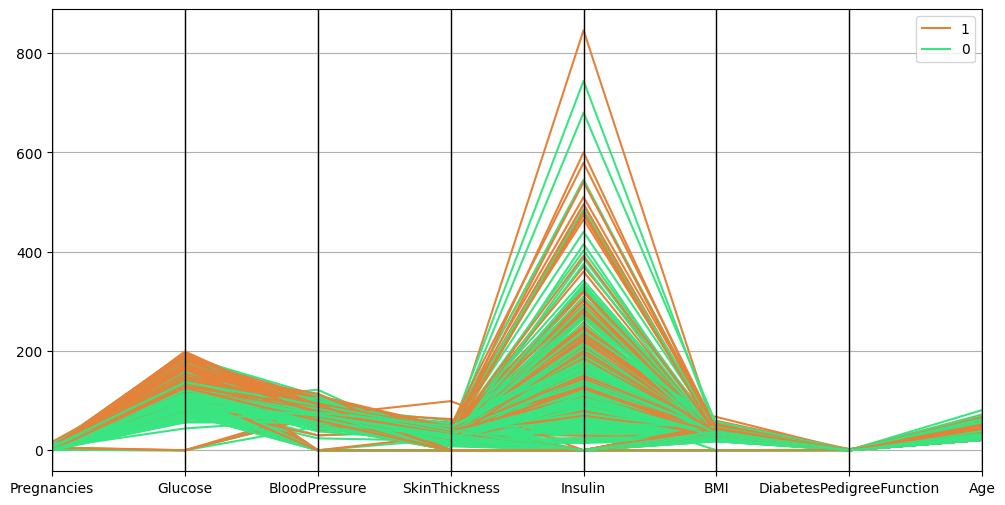

'\nINTERPRETACIÓN:\n\nEl gráfico permite comparar el comportamiento\nde las variables médicas entre pacientes\ncon y sin diabetes.\n\nSe observan diferencias en variables\ncomo Glucose y BMI según la clase Outcome.\n\nEste tipo de visualización ayuda a detectar\nqué variables podrían aportar mayor capacidad predictiva.\n'

In [13]:
# =========================
# VISUALIZACIÓN DE VARIABLES
# =========================

# Importamos matplotlib para generar gráficos

import matplotlib.pyplot as plt

# Definimos el tamaño del gráfico

plt.figure(figsize=(12, 6))

# Creamos un gráfico de coordenadas paralelas
# Cada línea representa un paciente
# y el color indica si tiene diabetes o no

pd.plotting.parallel_coordinates(
    total_data,
    "Outcome",
    color=("#E58139", "#39E581")
)

# Mostramos el gráfico

plt.show()

"""
INTERPRETACIÓN:

El gráfico permite comparar el comportamiento
de las variables médicas entre pacientes
con y sin diabetes.

Se observan diferencias en variables
como Glucose y BMI según la clase Outcome.

Este tipo de visualización ayuda a detectar
qué variables podrían aportar mayor capacidad predictiva.
"""


In [14]:
# =========================
# SEPARACIÓN FINAL DE DATOS
# =========================

# Separamos nuevamente las variables predictoras (X)
# y la variable objetivo (y) tanto en train como en test

# Eliminamos la columna Outcome de X
# porque es la variable que queremos predecir

X_train = train_data.drop(["Outcome"], axis=1)
y_train = train_data["Outcome"]

X_test = test_data.drop(["Outcome"], axis=1)
y_test = test_data["Outcome"]

# En este punto:
# X_train y X_test contienen únicamente las variables predictoras
# y_train y y_test contienen la variable objetivo

# Estos datos ya están preparados
# para entrenar y evaluar el modelo de Árbol de Decisión

In [15]:
# =========================
# ENTRENAMIENTO DEL MODELO
# =========================

# Importamos el modelo de Árbol de Decisión
# Este algoritmo permite clasificar datos
# mediante reglas y divisiones en forma de árbol

from sklearn.tree import DecisionTreeClassifier

# Creamos el modelo

# random_state=42 permite obtener siempre
# los mismos resultados al ejecutar el código,
# facilitando la reproducibilidad del proyecto

model = DecisionTreeClassifier(random_state=42)

# Entrenamos el modelo utilizando los datos train

# X_train -> variables predictoras
# y_train -> variable objetivo (Outcome)

model.fit(X_train, y_train)

# En este paso el modelo aprende patrones
# y relaciones entre las variables médicas
# para intentar predecir si un paciente
# tiene diabetes o no

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

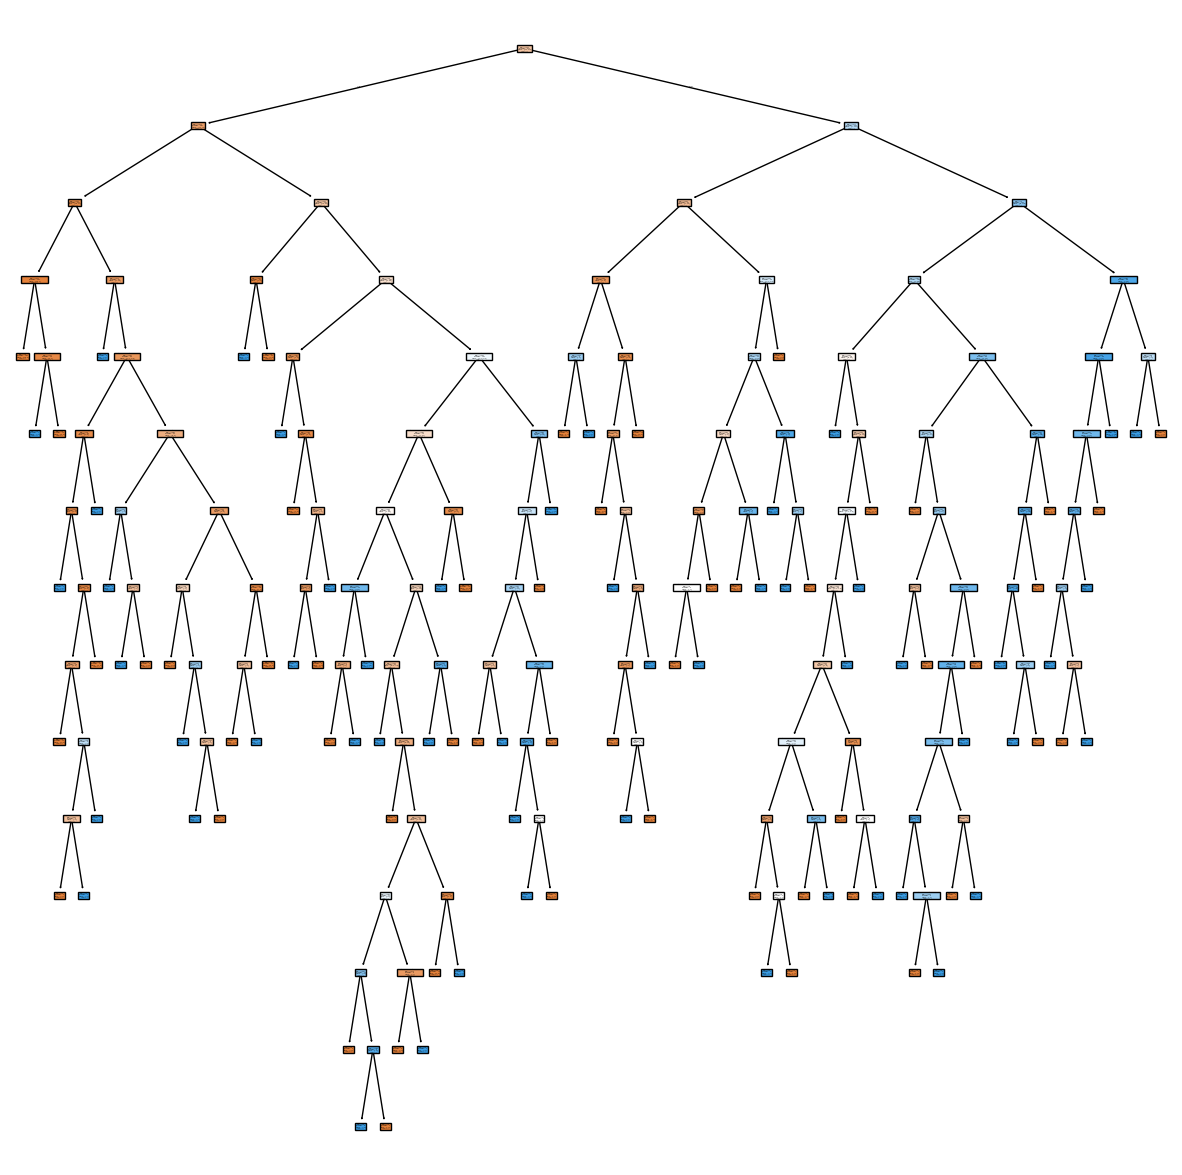

In [16]:
# =========================
# VISUALIZACIÓN DEL ÁRBOL
# =========================

# Importamos las herramientas necesarias
# desde sklearn para visualizar el árbol

from sklearn import tree

# Definimos el tamaño de la figura
# Un tamaño grande ayuda a visualizar mejor
# las divisiones y nodos del árbol

fig = plt.figure(figsize=(15,15))

# Dibujamos el árbol de decisión

# feature_names:
# nombres de las variables predictoras

# class_names:
# nombres de las clases objetivo
# En este dataset:
# 0 -> no diabetes
# 1 -> diabetes

# filled=True colorea los nodos
# según la clase predominante

tree.plot_tree(
    model,
    feature_names=list(X_train.columns),
    class_names=["0", "1"],
    filled=True
)

# Mostramos el gráfico

plt.show()

# Interpretación:
# El árbol representa las decisiones que toma el modelo
# para clasificar a los pacientes.

# Cada nodo contiene una condición
# basada en variables como Glucose o BMI.

# A medida que descendemos por el árbol,
# el modelo separa los pacientes según
# la probabilidad de padecer diabetes.

In [17]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [18]:
# =========================
# EVALUACIÓN DEL MODELO
# =========================

# Importamos accuracy_score
# Esta métrica permite medir
# qué porcentaje de predicciones
# fueron correctas

from sklearn.metrics import accuracy_score

# Calculamos la precisión del modelo

# y_test -> valores reales
# y_pred -> predicciones realizadas por el modelo

accuracy = accuracy_score(y_test, y_pred)

# Mostramos el resultado

print("Accuracy del modelo:", accuracy)

# Interpretación:
# El accuracy representa el porcentaje de pacientes
# clasificados correctamente por el árbol de decisión.

# Un valor cercano a 1 indica mejor rendimiento.
# Por ejemplo:
# 0.80 = 80% de predicciones correctas.

Accuracy del modelo: 0.7597402597402597


In [19]:
# =========================
# OPTIMIZACIÓN DEL MODELO
# =========================

# Importamos GridSearchCV
# Esta herramienta permite probar automáticamente
# múltiples combinaciones de hiperparámetros
# para encontrar el mejor modelo posible

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Definimos los hiperparámetros que queremos probar

hyperparams = {

    # criterion:
    # método utilizado para medir la calidad
    # de las divisiones del árbol

    # gini -> índice de Gini
    # entropy -> ganancia de información

    "criterion": ["gini", "entropy"],

    # max_depth:
    # profundidad máxima del árbol

    # árboles muy profundos pueden provocar overfitting

    "max_depth": [None, 5, 10, 20],

    # min_samples_split:
    # número mínimo de muestras necesarias
    # para dividir un nodo

    "min_samples_split": [2, 5, 10],

    # min_samples_leaf:
    # número mínimo de muestras permitidas
    # en una hoja final

    "min_samples_leaf": [1, 2, 4]
}

# Creamos el modelo GridSearchCV

# scoring="accuracy":
# la métrica utilizada para comparar modelos

# cv=10:
# validación cruzada de 10 particiones
# ayuda a evaluar mejor el rendimiento real del modelo

grid = GridSearchCV(
    model,
    hyperparams,
    scoring="accuracy",
    cv=10
)

# Mostramos el objeto creado

grid

# Interpretación:
# GridSearchCV probará automáticamente distintas
# combinaciones de hiperparámetros para encontrar
# la configuración con mejor accuracy.

# Esto permite optimizar el árbol de decisión
# y reducir problemas como overfitting o underfitting.

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [20]:
# =========================
# ENTRENAMIENTO DEL GRID SEARCH
# =========================

# Algunas versiones de sklearn pueden mostrar
# warnings durante la optimización del modelo.

# Este bloque sirve para ocultar warnings
# y mantener la salida más limpia y legible.

def warn(*args, **kwargs):
    pass

import warnings
warnings.warn = warn

# Entrenamos GridSearchCV utilizando
# los datos de entrenamiento

# GridSearch probará automáticamente
# múltiples combinaciones de hiperparámetros
# para encontrar el mejor modelo

grid.fit(X_train, y_train)

# Mostramos los mejores hiperparámetros encontrados

print(f"Best hyperparameters: {grid.best_params_}")

# Interpretación:
# GridSearchCV selecciona automáticamente
# la combinación de parámetros que obtiene
# el mejor accuracy durante la validación cruzada.

# Esto permite optimizar el árbol de decisión
# y mejorar su capacidad predictiva.

Best hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [21]:
# =========================
# ENTRENAMIENTO DEL MODELO OPTIMIZADO
# =========================

# Creamos un nuevo Árbol de Decisión
# utilizando los mejores hiperparámetros
# obtenidos mediante GridSearchCV

model = DecisionTreeClassifier(

    # criterion:
    # método utilizado para calcular
    # la calidad de las divisiones del árbol

    # entropy utiliza ganancia de información

    criterion="entropy",

    # max_depth:
    # limita la profundidad máxima del árbol
    # para evitar overfitting

    max_depth=5,

    # min_samples_leaf:
    # número mínimo de muestras permitidas
    # en una hoja final

    min_samples_leaf=4,

    # min_samples_split:
    # mínimo de muestras necesarias
    # para dividir un nodo

    min_samples_split=2,

    # random_state:
    # asegura reproducibilidad de resultados

    random_state=42
)

# Entrenamos el modelo optimizado
# utilizando los datos de entrenamiento

model.fit(X_train, y_train)

# Interpretación:
# Este nuevo modelo utiliza la mejor combinación
# de hiperparámetros encontrada durante GridSearchCV.

# El objetivo es mejorar la capacidad predictiva
# y reducir problemas como overfitting,
# obteniendo un árbol más equilibrado y generalizable.

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [22]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [23]:
# =========================
# EVALUACIÓN DEL MODELO OPTIMIZADO
# =========================

# Importamos accuracy_score
# para medir la precisión del modelo

from sklearn.metrics import accuracy_score

# Generamos predicciones utilizando
# el modelo optimizado

y_pred = model.predict(X_test)

# Calculamos el accuracy comparando:
# y_test -> valores reales
# y_pred -> predicciones del modelo

accuracy = accuracy_score(y_test, y_pred)

# Mostramos el resultado final

print("Accuracy del modelo optimizado:", accuracy)

# Interpretación:
# Este accuracy permite evaluar
# el rendimiento del árbol optimizado.

# Si el valor es superior al modelo inicial,
# significa que la optimización mediante
# GridSearchCV ha mejorado la capacidad predictiva.

# Un accuracy más alto indica que el modelo
# clasifica correctamente una mayor cantidad
# de pacientes con y sin diabetes.

Accuracy del modelo optimizado: 0.7727272727272727


In [25]:
# =========================
# GUARDAR MODELO ENTRENADO
# =========================

# Importamos:
# dump -> permite guardar el modelo entrenado
# en un archivo .sav para reutilizarlo después

from pickle import dump

# Importamos os para crear carpetas

import os

# Creamos la carpeta models si no existe
# exist_ok=True evita errores si ya está creada

os.makedirs("../models", exist_ok=True)

# Guardamos el modelo entrenado

# "wb" significa:
# write binary -> escritura en formato binario

# El archivo .sav almacenará:
# - estructura del árbol
# - hiperparámetros
# - entrenamiento realizado

dump(
    model,
    open(
        "../models/tree_classifier_crit-entro_maxdepth-5_minleaf-4_minsplit2_42.sav",
        "wb"
    )
)

print("Modelo guardado correctamente.")

# Interpretación:
# Guardar el modelo permite reutilizarlo posteriormente
# sin necesidad de volver a entrenarlo.

# Esto es útil para:
# - hacer predicciones futuras
# - desplegar modelos
# - reutilizar el trabajo realizado

Modelo guardado correctamente.
